# MLTS — Lecture 3 Practice
## Bayesian Inference

This notebook accompanies **Lecture 3** of the MLTS course summary. Bayesian inference is
the conceptual scaffold for the next several lectures (GP regression in L4, Kalman in L6,
particle filters in L7), so it pays to get comfortable here.

**You will learn how to:**
1. Apply Bayes' theorem iteratively — watch a posterior march from 1% to 99% over three
   positive medical tests.
2. Use a **conjugate prior** (Beta–Binomial) and see why conjugacy = closed-form posterior.
3. Build a **Bayesian linear regression** from scratch — posterior over weights, then the
   predictive distribution with its characteristic "uncertainty fans out" shape.
4. Use **marginal likelihood** to pick the right model complexity automatically — the
   Bayesian Occam's razor.

**Prerequisites:** `numpy`, `scipy`, `matplotlib`, `scikit-learn`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import beta as beta_dist
from scipy.stats import norm

rng = np.random.default_rng(seed=42)
plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1 · Bayes' theorem in action — the disease test

Bayes' theorem:
$$P(A \mid B) = \frac{P(B \mid A)\, P(A)}{P(B)}$$

Lecture example:
- $A$: having the disease — prior $P(A) = 0.01$
- $B$: positive test — likelihood $P(B \mid A) = 0.95$
- False positive: $P(B \mid \neg A) = 1 - 0.95 = 0.05$ (equal sensitivity & specificity)

After a positive test we update $P(A)$. After a *second* positive test we apply Bayes
again, with the previous posterior as the new prior. The posterior climbs:
**1% → 16.1% → 78.5% → 98.6%**.


Iterative Bayesian updates after each positive test:
  After 0 positive tests: P(disease) = 0.0100
  After 1 positive tests: P(disease) = 0.1610
  After 2 positive tests: P(disease) = 0.7848
  After 3 positive tests: P(disease) = 0.9858
  After 4 positive tests: P(disease) = 0.9992
  After 5 positive tests: P(disease) = 1.0000


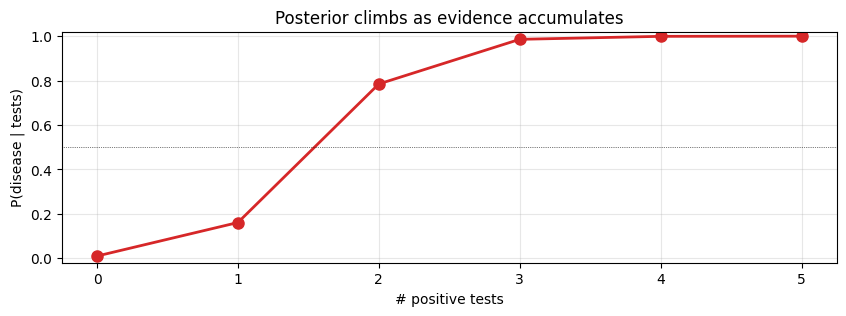

In [2]:
def bayes_update(prior, likelihood_pos_given_A, likelihood_pos_given_notA):
    """One Bayesian update on a binary hypothesis after a positive observation."""
    numer = likelihood_pos_given_A * prior
    marginal = (likelihood_pos_given_A * prior
                + likelihood_pos_given_notA * (1 - prior))
    return numer / marginal

prior = 0.01
sens, spec = 0.95, 0.95          # sensitivity = P(+|A), specificity = P(-|~A)
fpr = 1 - spec                   # P(+|~A)

posterior_history = [prior]
for k in range(1, 6):
    posterior_history.append(bayes_update(posterior_history[-1], sens, fpr))

print("Iterative Bayesian updates after each positive test:")
for k, p in enumerate(posterior_history):
    print(f"  After {k} positive tests: P(disease) = {p:.4f}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(range(len(posterior_history)), posterior_history, 'o-', color='C3', lw=2, ms=8)
ax.axhline(0.5, color='k', ls=':', lw=0.5)
ax.set_xlabel('# positive tests'); ax.set_ylabel('P(disease | tests)')
ax.set_title('Posterior climbs as evidence accumulates')
ax.set_ylim(-0.02, 1.02); plt.show()


**Take-home:** the *first* positive test gives only 16% probability of disease — far
below intuition. This is because the prior 1% is so low that even a 95%-accurate test
mostly catches false positives. Iteration is what builds confidence.


## 2 · Beta–Binomial conjugacy

When the likelihood is **Binomial** and the prior is **Beta**, the posterior is also Beta —
this is the textbook example of conjugacy. Specifically:

$$\theta \sim \text{Beta}(\alpha, \beta), \quad x \mid \theta \sim \text{Bin}(n, \theta)$$
$$\Rightarrow \theta \mid x \sim \text{Beta}(\alpha + x, \beta + n - x).$$

The hyperparameters $(\alpha, \beta)$ have a beautiful interpretation: $\alpha - 1$ is the
"prior number of successes" and $\beta - 1$ is the "prior number of failures". This makes
priors easy to specify.


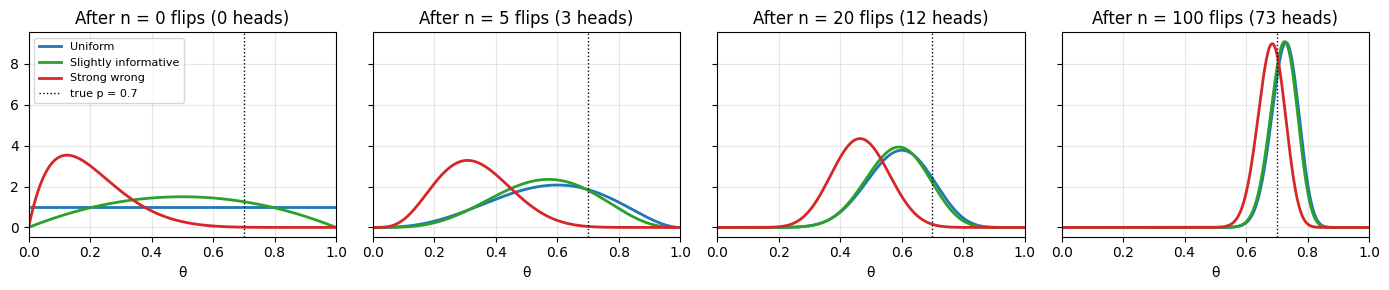

Note how the 'strong wrong' prior dominates early but is eventually overwhelmed by data.


In [3]:
def plot_beta(ax, a, b, label, color, ls='-'):
    xs = np.linspace(0.001, 0.999, 400)
    ax.plot(xs, beta_dist.pdf(xs, a, b), label=label, color=color, ls=ls, lw=2)

# True coin bias
true_p = 0.7

# Prior options
priors = {
    'Uniform — Beta(1, 1)':        (1, 1),
    'Slightly informative — Beta(2, 2)': (2, 2),
    'Strong wrong — Beta(2, 8)':   (2, 8),  # believes coin is biased toward tails
}

# Sequence of observations (1=heads, 0=tails)
observations = (rng.uniform(size=200) < true_p).astype(int)
n_obs_to_show = [0, 5, 20, 100]

fig, axes = plt.subplots(1, len(n_obs_to_show), figsize=(14, 3), sharey=True)
for ax, n in zip(axes, n_obs_to_show):
    heads = observations[:n].sum()
    for (label, (a0, b0)), color in zip(priors.items(), ['C0', 'C2', 'C3']):
        a_post, b_post = a0 + heads, b0 + (n - heads)
        plot_beta(ax, a_post, b_post, label.split(' — ')[0], color)
    ax.axvline(true_p, color='k', ls=':', lw=1, label=f'true p = {true_p}')
    ax.set_title(f'After n = {n} flips ({heads} heads)')
    ax.set_xlabel('θ'); ax.set_xlim(0, 1)

axes[0].legend(loc='upper left', fontsize=8); plt.tight_layout(); plt.show()
print("Note how the 'strong wrong' prior dominates early but is eventually overwhelmed by data.")


## 3 · Bayesian linear regression — posterior over weights

For the model $y = Xw + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, \sigma^2 I)$, with a Gaussian prior
$w \sim \mathcal{N}(w_0, V_0)$, the posterior is also Gaussian:

$$p(w \mid X, y, \sigma^2) = \mathcal{N}(w \mid w_N, V_N)$$

with (slide formulas)
$$V_N = \sigma^2(\sigma^2 V_0^{-1} + X^\top X)^{-1}$$
$$w_N = V_N\!\left(V_0^{-1} w_0 + \tfrac{1}{\sigma^2} X^\top y\right).$$

We will:
1. Fit a 2-parameter linear model $y = w_0 + w_1 x$ to a small dataset.
2. Plot the prior, the posterior, and several lines drawn from the posterior.


In [4]:
def bayes_linreg(X, y, sigma2, w0, V0):
    """Closed-form Bayesian linear regression with known noise variance."""
    V0_inv = np.linalg.inv(V0)
    V_N = sigma2 * np.linalg.inv(sigma2 * V0_inv + X.T @ X)
    w_N = V_N @ (V0_inv @ w0 + X.T @ y / sigma2)
    return w_N, V_N

# Synthetic data: y = 0.5 + 1.2 * x + noise
true_w = np.array([0.5, 1.2])
N = 8
x_data = rng.uniform(-3, 3, N)
sigma_noise = 0.5
y_data = true_w[0] + true_w[1] * x_data + rng.normal(0, sigma_noise, N)
X_data = np.column_stack([np.ones(N), x_data])  # design matrix with intercept

# Vague prior centred at 0
w0_prior = np.zeros(2)
V0_prior = np.eye(2) * 5.0**2  # std 5 for each weight

w_N, V_N = bayes_linreg(X_data, y_data, sigma_noise**2, w0_prior, V0_prior)

print(f"True weights        : {true_w}")
print(f"Posterior mean      : {np.round(w_N, 3)}")
print(f"Posterior std       : {np.round(np.sqrt(np.diag(V_N)), 3)}")
# How many σ away is each true weight from the posterior mean?
z_scores = np.abs(true_w - w_N) / np.sqrt(np.diag(V_N))
print(f"|true - post|/std   : {np.round(z_scores, 2)}  (smaller = better)")
print()
print("With only 8 points and σ=0.5 noise, the intercept is genuinely under-determined —")
print("the posterior std on w0 reflects this honestly. That's the Bayesian advantage:")
print("the model tells you when it isn't sure.")


True weights        : [0.5 1.2]
Posterior mean      : [0.114 1.14 ]
Posterior std       : [0.181 0.09 ]
|true - post|/std   : [2.14 0.66]  (smaller = better)

With only 8 points and σ=0.5 noise, the intercept is genuinely under-determined —
the posterior std on w0 reflects this honestly. That's the Bayesian advantage:
the model tells you when it isn't sure.


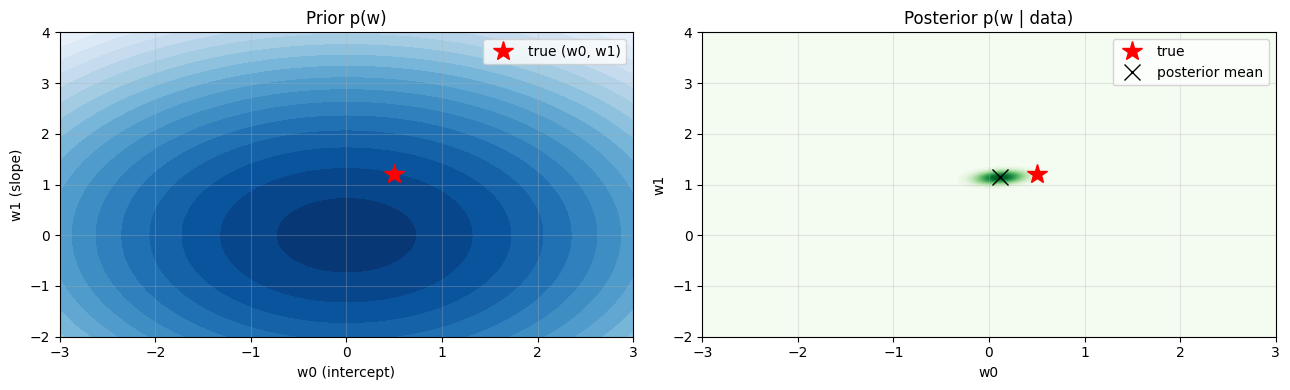

In [5]:
# Visualise prior and posterior in weight space
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
w0_grid, w1_grid = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-2, 4, 200))
grid = np.stack([w0_grid.ravel(), w1_grid.ravel()], axis=1)

prior_pdf = stats.multivariate_normal(w0_prior, V0_prior).pdf(grid).reshape(w0_grid.shape)
post_pdf  = stats.multivariate_normal(w_N, V_N).pdf(grid).reshape(w0_grid.shape)

axes[0].contourf(w0_grid, w1_grid, prior_pdf, levels=20, cmap='Blues')
axes[0].plot(*true_w, 'r*', ms=15, label='true (w0, w1)')
axes[0].set_xlabel('w0 (intercept)'); axes[0].set_ylabel('w1 (slope)')
axes[0].set_title('Prior p(w)'); axes[0].legend()

axes[1].contourf(w0_grid, w1_grid, post_pdf, levels=20, cmap='Greens')
axes[1].plot(*true_w, 'r*', ms=15, label='true')
axes[1].plot(*w_N,    'kx', ms=12, label='posterior mean')
axes[1].set_xlabel('w0'); axes[1].set_ylabel('w1')
axes[1].set_title('Posterior p(w | data)'); axes[1].legend()
plt.tight_layout(); plt.show()


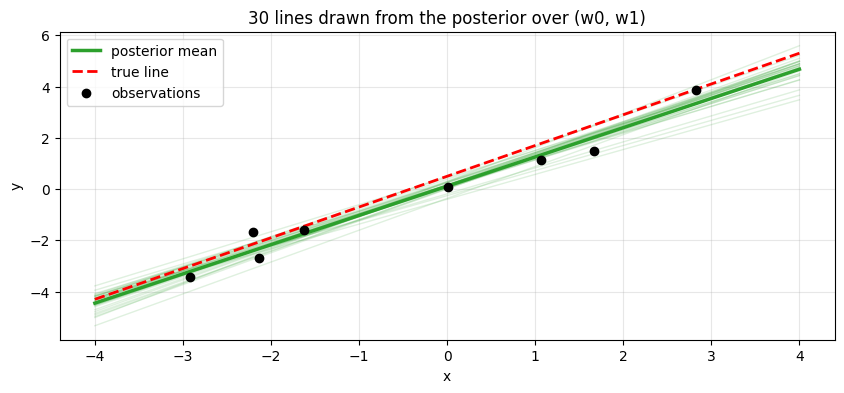

In [6]:
# Sample lines from the posterior — these are *plausible regression lines* given the data
n_samples = 30
w_samples = rng.multivariate_normal(w_N, V_N, n_samples)
xs_plot = np.linspace(-4, 4, 100)

fig, ax = plt.subplots(figsize=(10, 4))
for w in w_samples:
    ax.plot(xs_plot, w[0] + w[1]*xs_plot, color='C2', alpha=0.15, lw=1)
# Posterior mean line
ax.plot(xs_plot, w_N[0] + w_N[1]*xs_plot, color='C2', lw=2.5, label='posterior mean')
# True line
ax.plot(xs_plot, true_w[0] + true_w[1]*xs_plot, 'r--', lw=2, label='true line')
# Data
ax.scatter(x_data, y_data, color='black', zorder=3, label='observations')
ax.legend(); ax.set_title(f'{n_samples} lines drawn from the posterior over (w0, w1)')
ax.set_xlabel('x'); ax.set_ylabel('y'); plt.show()


## 4 · Predictive distribution — uncertainty fans out away from data

For a test input $x_*$, the posterior predictive is also Gaussian:
$$p(y_* \mid x_*, \mathcal{D}) = \mathcal{N}(y_* \mid w_N^\top x_*, \sigma_N^2(x_*))$$
$$\sigma_N^2(x_*) = \sigma^2 + x_*^\top V_N x_*$$

The variance has two pieces:
- $\sigma^2$ — irreducible noise we can never get rid of.
- $x_*^\top V_N x_*$ — uncertainty from not knowing $w$ exactly. **This term grows when
  $x_*$ is far from the training inputs**, which produces the classic "uncertainty cone"
  shape.


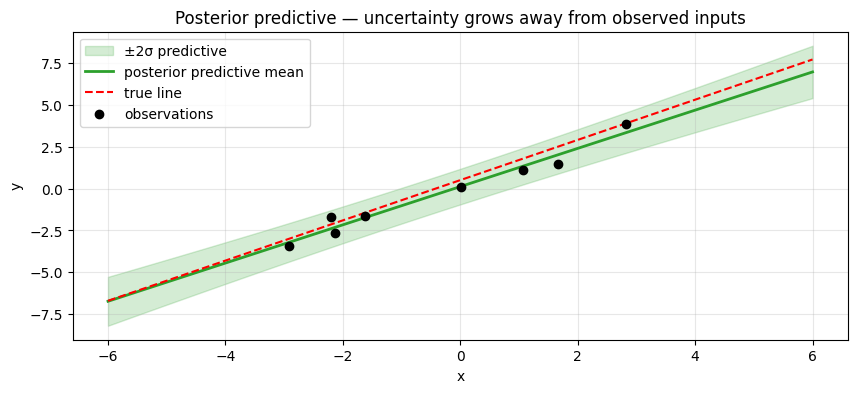

The narrowest band is in the centre of the data; it widens at both ends.
This is the Bayesian gift you don't get from OLS: an honest uncertainty estimate.


In [7]:
def predictive(X_new, w_N, V_N, sigma2):
    mean = X_new @ w_N
    var  = sigma2 + np.einsum('ij,jk,ik->i', X_new, V_N, X_new)
    return mean, np.sqrt(var)

xs_plot = np.linspace(-6, 6, 200)
X_plot = np.column_stack([np.ones_like(xs_plot), xs_plot])
mu_pred, std_pred = predictive(X_plot, w_N, V_N, sigma_noise**2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(xs_plot, mu_pred - 2*std_pred, mu_pred + 2*std_pred,
                color='C2', alpha=0.2, label='±2σ predictive')
ax.plot(xs_plot, mu_pred, color='C2', lw=2, label='posterior predictive mean')
ax.plot(xs_plot, true_w[0] + true_w[1]*xs_plot, 'r--', lw=1.5, label='true line')
ax.scatter(x_data, y_data, color='black', zorder=3, label='observations')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend()
ax.set_title('Posterior predictive — uncertainty grows away from observed inputs')
plt.show()
print("The narrowest band is in the centre of the data; it widens at both ends.")
print("This is the Bayesian gift you don't get from OLS: an honest uncertainty estimate.")


## 5 · Bayesian Occam's razor — model selection via marginal likelihood

The **marginal likelihood** (a.k.a. *evidence*) is:
$$p(\mathcal{D} \mid M_i) = \int p(\mathcal{D} \mid \theta, M_i)\, p(\theta \mid M_i)\, d\theta.$$

Models that are **too simple** can't generate $\mathcal{D}$ → small evidence.
Models that are **too complex** can generate many possible datasets → their probability mass
is spread thin → also small evidence for any one $\mathcal{D}$.
The "just right" model achieves the highest evidence — Occam's razor for free.

For Bayesian linear regression with Gaussian prior, the log-evidence has a closed form:
$$\log p(\mathcal{D}) = -\tfrac{N}{2}\log(2\pi\sigma^2) - \tfrac{1}{2}\log\det(I + \sigma^{-2}X V_0 X^\top) - \tfrac{1}{2}(y - X w_0)^\top (\sigma^2 I + X V_0 X^\top)^{-1}(y - X w_0).$$

We will fit polynomial models of degree 1, 2, 3 to a small ($N=5$) and a larger ($N=30$)
dataset and pick the model by evidence.


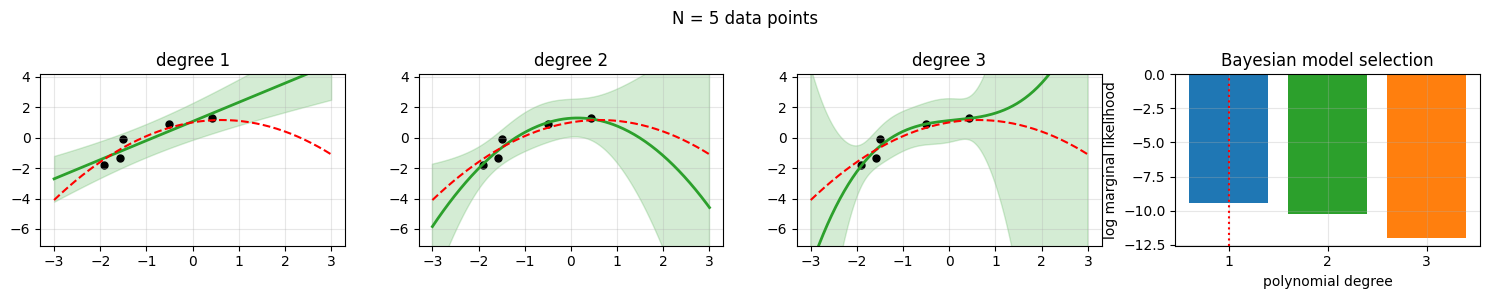

  N=5: log evidences = ['-9.42', '-10.28', '-11.98'] -> best degree = 1



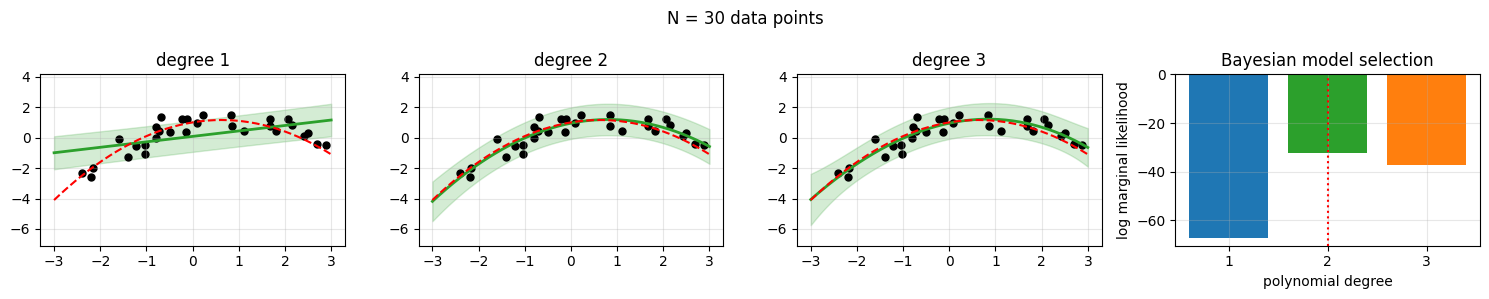

  N=30: log evidences = ['-67.08', '-32.35', '-37.24'] -> best degree = 2



In [8]:
def log_marginal_likelihood(X, y, sigma2, w0, V0):
    """Log evidence p(D | M) for Bayesian linear regression with Gaussian prior."""
    N = len(y)
    # Marginal of y is N(X w0, sigma2 I + X V0 X^T)
    cov = sigma2 * np.eye(N) + X @ V0 @ X.T
    mean = X @ w0
    return stats.multivariate_normal.logpdf(y, mean=mean, cov=cov)

def poly_design(x, degree):
    return np.column_stack([x**k for k in range(degree + 1)])

# True function: a quadratic
def true_fn(x): return 1.0 + 0.5*x - 0.4*x**2

sigma_n = 0.5
xs_dense = np.linspace(-3, 3, 200)

for N in [5, 30]:
    x = rng.uniform(-3, 3, N)
    y = true_fn(x) + rng.normal(0, sigma_n, N)

    fig, axes = plt.subplots(1, 4, figsize=(15, 3))
    log_evidences = []
    for ax, deg in zip(axes[:3], [1, 2, 3]):
        X = poly_design(x, deg)
        d = X.shape[1]
        w0 = np.zeros(d)
        V0 = np.eye(d) * 4.0**2
        w_N, V_N = bayes_linreg(X, y, sigma_n**2, w0, V0)

        X_plot = poly_design(xs_dense, deg)
        mu, std = predictive(X_plot, w_N, V_N, sigma_n**2)
        ax.fill_between(xs_dense, mu - 2*std, mu + 2*std, color='C2', alpha=0.2)
        ax.plot(xs_dense, mu, 'C2', lw=2, label='posterior')
        ax.plot(xs_dense, true_fn(xs_dense), 'r--', lw=1.5, label='true')
        ax.scatter(x, y, color='black', s=25)
        ax.set_title(f'degree {deg}')
        ax.set_ylim(true_fn(xs_dense).min()-3, true_fn(xs_dense).max()+3)

        log_ev = log_marginal_likelihood(X, y, sigma_n**2, w0, V0)
        log_evidences.append(log_ev)

    # Bar chart of evidences
    axes[3].bar([1, 2, 3], log_evidences, color=['C0', 'C2', 'C1'])
    axes[3].set_xticks([1, 2, 3]); axes[3].set_xlabel('polynomial degree')
    axes[3].set_ylabel('log marginal likelihood'); axes[3].set_title('Bayesian model selection')
    best = 1 + np.argmax(log_evidences)
    axes[3].axvline(best, color='red', ls=':')

    plt.suptitle(f'N = {N} data points')
    plt.tight_layout(); plt.show()
    print(f"  N={N}: log evidences = {[f'{e:.2f}' for e in log_evidences]} "
          f"-> best degree = {best}")
    print()


**Take-home:** with **N=5** points the linear model often wins because there is not enough
data to justify the extra parameters of degree-2 or degree-3 — Occam's razor in action.
With **N=30** the truth (degree 2) becomes the evidence-best choice, and degree-3 is
penalised for being unnecessarily flexible. *This works without a separate validation set.*


---

# Exercises


## Exercise 1 — Sequential Bayesian updating

Implement the following:

1. Start with a vague Beta prior on the bias of a coin: $\theta \sim \text{Beta}(1, 1)$
   (uniform on [0, 1]).
2. Generate 50 flips of a coin with true bias 0.65.
3. **Update one observation at a time** — compute the posterior after 1 flip, 2 flips, etc.
4. Plot:
   - The posterior PDF every 10 flips on a single chart.
   - The posterior mean and 95% credible interval as a function of $n$.


### Solution

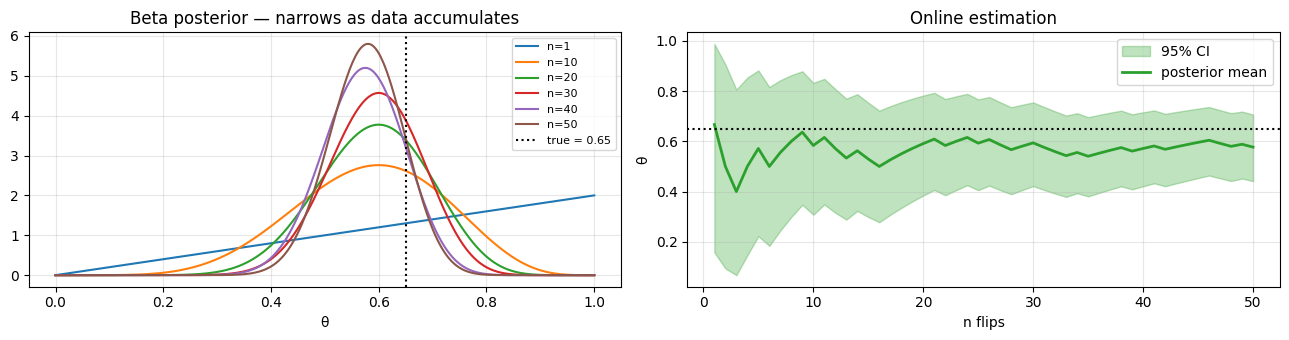

Final posterior: Beta(30, 22) — mean 0.577, true 0.65


In [9]:
true_theta = 0.65
n_flips = 50
flips = (rng.uniform(size=n_flips) < true_theta).astype(int)

# Track posterior parameters online
a, b = 1.0, 1.0     # Beta(1, 1) prior
post_means, post_lo, post_hi = [], [], []
posteriors_to_plot = {}
for k, x in enumerate(flips, start=1):
    a += x          # success increments alpha
    b += 1 - x      # failure increments beta
    post_means.append(a / (a + b))
    post_lo.append(beta_dist.ppf(0.025, a, b))
    post_hi.append(beta_dist.ppf(0.975, a, b))
    if k % 10 == 0 or k == 1:
        posteriors_to_plot[k] = (a, b)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

# Left: posterior PDF every 10 flips
xs = np.linspace(0, 1, 400)
for n_seen, (aa, bb) in posteriors_to_plot.items():
    axes[0].plot(xs, beta_dist.pdf(xs, aa, bb), label=f'n={n_seen}')
axes[0].axvline(true_theta, color='k', ls=':', label=f'true = {true_theta}')
axes[0].set_title('Beta posterior — narrows as data accumulates')
axes[0].set_xlabel('θ'); axes[0].legend(fontsize=8)

# Right: posterior mean + 95% CI
ks = np.arange(1, n_flips + 1)
axes[1].fill_between(ks, post_lo, post_hi, color='C2', alpha=0.3, label='95% CI')
axes[1].plot(ks, post_means, color='C2', lw=2, label='posterior mean')
axes[1].axhline(true_theta, color='k', ls=':')
axes[1].set_xlabel('n flips'); axes[1].set_ylabel('θ')
axes[1].set_title('Online estimation'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Final posterior: Beta({a:.0f}, {b:.0f}) — mean {a/(a+b):.3f}, true {true_theta}")


## Exercise 2 — Bayesian linear regression from scratch vs sklearn

`sklearn` ships a `BayesianRidge` regressor. It uses an **automatic relevance determination**
prior (each weight has its own variance, learned from the data), so the *exact* numbers will
differ from a fixed prior, but the posterior means should be close on a well-conditioned
problem.

1. Generate $N = 60$ samples from $y = 1 - 0.5x + 0.2x^2 + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.5^2)$.
2. Fit your `bayes_linreg` (degree-2 features, fixed Gaussian prior) and `BayesianRidge`.
3. Compare predicted means and the predictive standard deviations on a grid.


### Solution

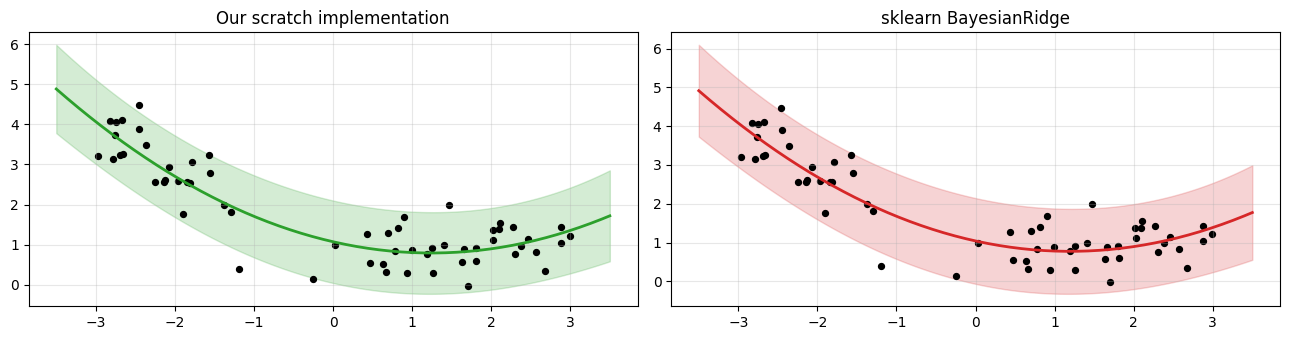

Our   posterior mean weights : [ 1.076 -0.451  0.182]
sklearn coef + intercept     : [ 1.041 -0.449  0.188]
True coefficients            : [ 1.0, -0.5,  0.2]

The fits are visually indistinguishable; the small numerical gap is because
sklearn learns the noise variance and the prior precision from the data, while
we hard-coded sigma2 = 0.25 and prior variance 16.


In [10]:
from sklearn.linear_model import BayesianRidge

# Data
N = 60
x_data = rng.uniform(-3, 3, N)
y_data = 1 - 0.5*x_data + 0.2*x_data**2 + rng.normal(0, 0.5, N)
X_data = np.column_stack([np.ones(N), x_data, x_data**2])

# 1) Our scratch version
sigma2 = 0.5**2
w0, V0 = np.zeros(3), np.eye(3) * 4.0**2
w_N, V_N = bayes_linreg(X_data, y_data, sigma2, w0, V0)

# 2) sklearn
br = BayesianRidge(fit_intercept=False)  # we built our own intercept column
br.fit(X_data, y_data)

# Compare on a grid
xs = np.linspace(-3.5, 3.5, 200)
X_grid = np.column_stack([np.ones_like(xs), xs, xs**2])

mu_ours, std_ours = predictive(X_grid, w_N, V_N, sigma2)
mu_skl, std_skl = br.predict(X_grid, return_std=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].fill_between(xs, mu_ours - 2*std_ours, mu_ours + 2*std_ours, color='C2', alpha=0.2)
axes[0].plot(xs, mu_ours, 'C2', lw=2, label='ours')
axes[0].scatter(x_data, y_data, s=18, color='k')
axes[0].set_title('Our scratch implementation')

axes[1].fill_between(xs, mu_skl - 2*std_skl, mu_skl + 2*std_skl, color='C3', alpha=0.2)
axes[1].plot(xs, mu_skl, 'C3', lw=2, label='sklearn BayesianRidge')
axes[1].scatter(x_data, y_data, s=18, color='k')
axes[1].set_title('sklearn BayesianRidge')
plt.tight_layout(); plt.show()

print(f"Our   posterior mean weights : {np.round(w_N, 3)}")
print(f"sklearn coef + intercept     : {np.round(br.coef_, 3)}")
print(f"True coefficients            : [ 1.0, -0.5,  0.2]")
print()
print("The fits are visually indistinguishable; the small numerical gap is because")
print("sklearn learns the noise variance and the prior precision from the data, while")
print("we hard-coded sigma2 = 0.25 and prior variance 16.")


## Exercise 3 — Marginal likelihood for model selection on AirPassengers

Recall AirPassengers from L2. We will use **marginal likelihood** to choose the polynomial
degree of a trend model — without a separate validation set.

1. Detrend the log-passengers series by polynomial fits of degree 1, 2, 3, 4.
2. Compute the log marginal likelihood of each.
3. The model with the highest evidence wins. Plot the chosen trend.

(Note: *log* passengers because the multiplicative seasonality becomes additive there, which
is what makes a polynomial trend reasonable.)


### Solution

Noise variance estimate (from differencing): σ² = 0.00564

Polynomial degree -> log evidence:
  deg 1: log p(D | M) =    -16.94
  deg 2: log p(D | M) =     -8.88
  deg 3: log p(D | M) =    -15.09
  deg 4: log p(D | M) =    -21.13

Best model: polynomial degree 2


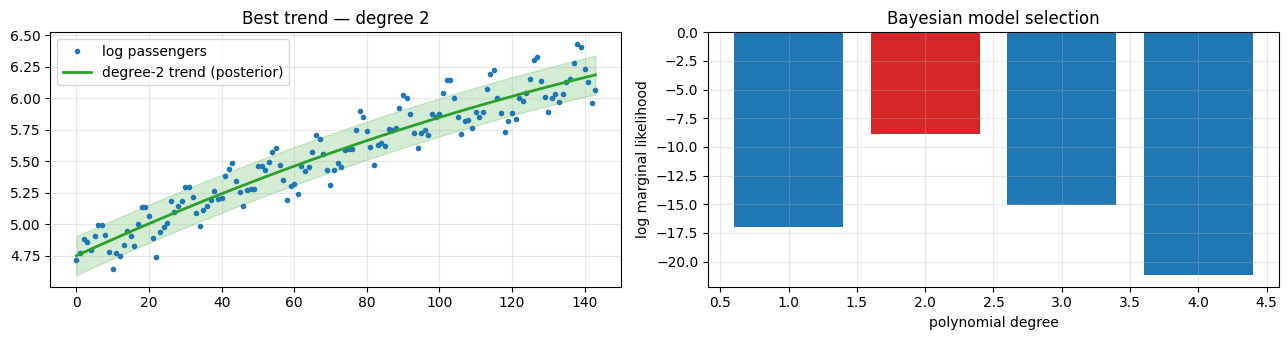


Notes:
  - The evidence isn't always monotone in degree — that's the whole point.
  - For the residuals after subtracting the trend you'd add seasonality terms.
  - The 'noise variance' here lumps trend mis-fit + seasonality + actual noise,
    which is why the absolute evidences should be compared *relatively*, not
    interpreted as calibrated probabilities.


In [11]:
# AirPassengers data (bundled inline — same as L2)
passengers = np.array([
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432,
])
y_log = np.log(passengers)
N = len(y_log)
t = np.arange(N)
t_norm = (t - t.mean()) / t.std()  # normalise for numerical stability

sigma2 = np.var(np.diff(y_log)) / 2  # crude noise estimate from differencing
print(f"Noise variance estimate (from differencing): σ² = {sigma2:.5f}")

log_evs = {}
for deg in [1, 2, 3, 4]:
    X = np.column_stack([t_norm**k for k in range(deg + 1)])
    d = X.shape[1]
    w0 = np.zeros(d)
    V0 = np.eye(d) * 5.0**2
    log_evs[deg] = log_marginal_likelihood(X, y_log, sigma2, w0, V0)

print()
print("Polynomial degree -> log evidence:")
for deg, le in log_evs.items():
    print(f"  deg {deg}: log p(D | M) = {le:+9.2f}")

best_deg = max(log_evs, key=log_evs.get)
print(f"\nBest model: polynomial degree {best_deg}")

# Plot the chosen trend
X_best = np.column_stack([t_norm**k for k in range(best_deg + 1)])
w0 = np.zeros(X_best.shape[1]); V0 = np.eye(X_best.shape[1]) * 5.0**2
w_N, V_N = bayes_linreg(X_best, y_log, sigma2, w0, V0)
mu, std = predictive(X_best, w_N, V_N, sigma2)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(t, y_log, 'C0.', label='log passengers')
axes[0].fill_between(t, mu - 2*std, mu + 2*std, color='C2', alpha=0.2)
axes[0].plot(t, mu, 'C2', lw=2, label=f'degree-{best_deg} trend (posterior)')
axes[0].set_title(f'Best trend — degree {best_deg}')
axes[0].legend()

axes[1].bar(list(log_evs.keys()), list(log_evs.values()),
            color=['C0' if d != best_deg else 'C3' for d in log_evs])
axes[1].set_xlabel('polynomial degree')
axes[1].set_ylabel('log marginal likelihood')
axes[1].set_title('Bayesian model selection')
plt.tight_layout(); plt.show()

print()
print("Notes:")
print("  - The evidence isn't always monotone in degree — that's the whole point.")
print("  - For the residuals after subtracting the trend you'd add seasonality terms.")
print("  - The 'noise variance' here lumps trend mis-fit + seasonality + actual noise,")
print("    which is why the absolute evidences should be compared *relatively*, not")
print("    interpreted as calibrated probabilities.")


---

## Recap

| Concept | Formula | Use |
|---------|---------|-----|
| Bayes' rule | $p(\theta \mid D) = \frac{p(D \mid \theta)\,p(\theta)}{p(D)}$ | Update belief after evidence |
| Conjugate prior | Posterior in same family as prior | Closed-form online learning |
| Beta–Binomial | $\text{Beta}(\alpha, \beta) + \text{Bin}(n, x) \to \text{Beta}(\alpha+x, \beta+n-x)$ | Coin-flip / click-through estimation |
| BLR posterior | $\mathcal{N}(w_N, V_N)$, closed form | Linear models with uncertainty |
| BLR predictive | $\mathcal{N}(w_N^\top x_*, \sigma^2 + x_*^\top V_N x_*)$ | Predictions + honest error bars |
| Marginal likelihood | $\int p(D \mid \theta) p(\theta) d\theta$ | Model selection without held-out data |

**Next:** Lecture 4 takes the Bayesian linear regression idea and lets us *put a prior on
functions themselves* — Gaussian Process regression. The predictive uncertainty cone you
saw above is a baby version of what GPs do for arbitrary feature spaces.
